In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("House_price_prediction.csv")

In [3]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [7]:
df.drop(columns=['date'], inplace=True)

In [8]:
df.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [16]:
X = pd.get_dummies(df.drop(columns=['price']), drop_first=True)
y = df['price']

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
X_train.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
1898,4.0,2.50,2770,45514,2.0,0,0,4,2770,0,...,False,False,False,False,False,False,False,False,False,False
1370,4.0,3.00,3720,29043,2.0,0,0,3,3720,0,...,False,False,False,False,False,False,False,False,False,False
3038,4.0,2.50,2810,11120,2.0,0,0,3,2810,0,...,False,False,False,False,False,False,False,False,False,False
2361,4.0,3.75,4030,10800,2.0,0,0,3,4030,0,...,False,False,False,False,False,False,False,False,False,False
156,3.0,2.00,2000,7000,2.0,0,0,3,2000,0,...,False,False,False,False,False,False,False,False,False,False


In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lm=LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

In [24]:
from sklearn.metrics import mean_squared_error,r2_score

In [25]:
y_pred=lm.predict(X_test)

In [26]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 4584212196634.328


In [27]:
r2_score=r2_score(y_test,y_pred)
print("R2_score Is:",r2_score)

R2_score Is: -3.495002841549117


In [29]:
y_train_pred = lm.predict(X_train)
y_test_pred  = lm.predict(X_test)

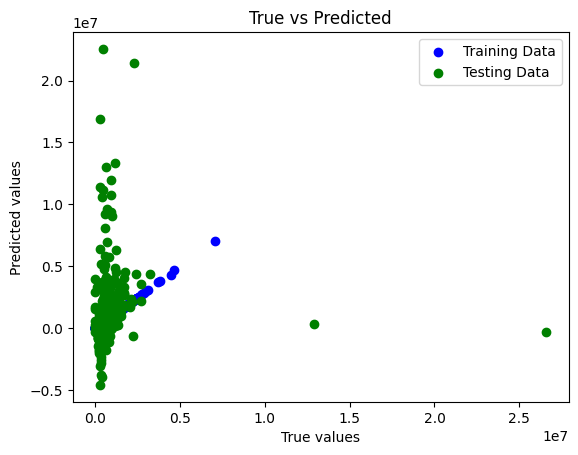

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_train, y_train_pred, color='blue', label='Training Data')
plt.scatter(y_test, y_test_pred, color='green', label='Testing Data')

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")
plt.legend()

plt.show()